# Tata Technologies TechPulse Applied AI/ML Laboratory
## Assignment 4: Vehicle Price Prediction

### Objective
Estimate vehicle resale price from structured vehicle data containing numerical and categorical attributes using regression models (**Linear Regression**, **Random Forest Regressor**, and **Gradient Boosting Regressor**).

### Key Components
- Synthetic dataset of **exactly 600 vehicles**.
- Categorical attributes: `brand` (`Toyota`, `Honda`, `Ford`, `BMW`, `Hyundai`), `fuel_type` (`Petrol`, `Diesel`, `Electric`).
- Numerical attributes: `age_years`, `mileage_km`, `engine_size_L`.
- Target attribute: `price`.
- Preprocessing via `ColumnTransformer` (`StandardScaler` for numeric, `OneHotEncoder` for categorical).
- Scikit-learn `Pipeline` encapsulation to prevent data leakage.
- Evaluation metrics: MAE, RMSE, and $R^2$ Score.
- Actual vs. Predicted price visualization for the best-performing model (lowest RMSE).


### 1. Import Required Libraries
Import standard Python modules for data manipulation, visualization, pipeline construction, preprocessing, regression modeling, and performance evaluation.


In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score

# Set plotting style and figure defaults
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11

print("Libraries imported successfully.")


Libraries imported successfully.


### 2. Synthetic Dataset Generation
Generate a synthetic dataset of exactly 600 vehicles with realistic physical relationships between vehicle specifications, brand tier, fuel system, and resale price.


In [2]:
# Set fixed random seed for reproducibility
np.random.seed(42)
n_samples = 600

# Categorical features
brands = ['Toyota', 'Honda', 'Ford', 'BMW', 'Hyundai']
brand_prob = [0.25, 0.25, 0.20, 0.15, 0.15]
brand = np.random.choice(brands, size=n_samples, p=brand_prob)

fuel_types = ['Petrol', 'Diesel', 'Electric']
fuel_prob = [0.50, 0.35, 0.15]
fuel_type = np.random.choice(fuel_types, size=n_samples, p=fuel_prob)

# Numerical features
age_years = np.random.randint(1, 16, size=n_samples)
mileage_km = age_years * np.random.uniform(8000, 18000, size=n_samples) + np.random.normal(5000, 2000, size=n_samples)
mileage_km = np.clip(mileage_km, 3000, 300000)
engine_size_L = np.random.choice([1.2, 1.5, 1.8, 2.0, 2.5, 3.0, 3.5], size=n_samples)

# Price formulation logic
brand_impact = {'Toyota': 2500, 'Honda': 2000, 'Ford': 0, 'BMW': 12000, 'Hyundai': -1000}
fuel_impact = {'Petrol': 0, 'Diesel': 1500, 'Electric': 5000}

base_price = 32000
age_penalty = age_years * 1400
mileage_penalty = (mileage_km / 10000.0) * 450
engine_bonus = (engine_size_L - 1.5) * 3500
brand_bonus = np.array([brand_impact[b] for b in brand])
fuel_bonus = np.array([fuel_impact[f] for f in fuel_type])
noise = np.random.normal(0, 2200, size=n_samples)

price = base_price - age_penalty - mileage_penalty + engine_bonus + brand_bonus + fuel_bonus + noise
price = np.round(np.clip(price, 3500, 85000), 2)

# Construct DataFrame
df = pd.DataFrame({
    'brand': brand,
    'fuel_type': fuel_type,
    'age_years': age_years,
    'mileage_km': np.round(mileage_km, 1),
    'engine_size_L': engine_size_L,
    'price': price
})

print(f"Dataset generated successfully ({len(df)} records).")
df.head()


Dataset generated successfully (600 records).


,brand,fuel_type,age_years,mileage_km,engine_size_L,price
0,Honda,Petrol,13,224272.4,3.5,10567.25
1,Hyundai,Petrol,12,130625.2,2.5,12282.65
2,BMW,Petrol,7,126275.5,2.0,28794.95
3,Ford,Petrol,13,117317.2,1.5,6275.83
4,Toyota,Petrol,11,196830.6,2.5,12624.17


### 3. Dataset Inspection
Examine dataset shape, column data types, descriptive statistics, and missing value status.


In [3]:
print("Dataset Dimensions (Rows, Columns):", df.shape)
print("\nColumn Data Types:")
print(df.dtypes)

print("\nMissing Values Check (`df.isna().sum()`):")
print(df.isna().sum())

print("\nCategorical Feature Value Counts:")
print("Brand Distribution:\n", df['brand'].value_counts())
print("\nFuel Type Distribution:\n", df['fuel_type'].value_counts())

print("\nDescriptive Statistics:")
df.describe()


Dataset Dimensions (Rows, Columns): (600, 6)

Column Data Types:
brand                str
fuel_type            str
age_years          int32
mileage_km       float64
engine_size_L    float64
price            float64
dtype: object

Missing Values Check (`df.isna().sum()`):
brand            0
fuel_type        0
age_years        0
mileage_km       0
engine_size_L    0
price            0
dtype: int64

Categorical Feature Value Counts:
Brand Distribution:
 brand
Toyota     155
Honda      133
Ford       126
Hyundai    102
BMW         84
Name: count, dtype: int64

Fuel Type Distribution:
 fuel_type
Petrol      300
Diesel      206
Electric     94
Name: count, dtype: int64

Descriptive Statistics:


,age_years,mileage_km,engine_size_L,price
count,600.000000,600.000000,600.000000,600.000000
mean,8.123333,109323.286167,2.190500,22198.655833
std,4.415195,60720.413185,0.778762,10190.678188
min,1.000000,9734.800000,1.200000,3500.000000
25%,4.000000,58620.575000,1.500000,14019.557500
50%,8.000000,107471.550000,2.000000,21853.325000
75%,12.000000,150844.475000,3.000000,29885.357500
max,15.000000,273122.700000,3.500000,51139.130000


### 4. Exploratory Data Analysis (EDA)
Visualize vehicle price distribution and feature relationships with price.


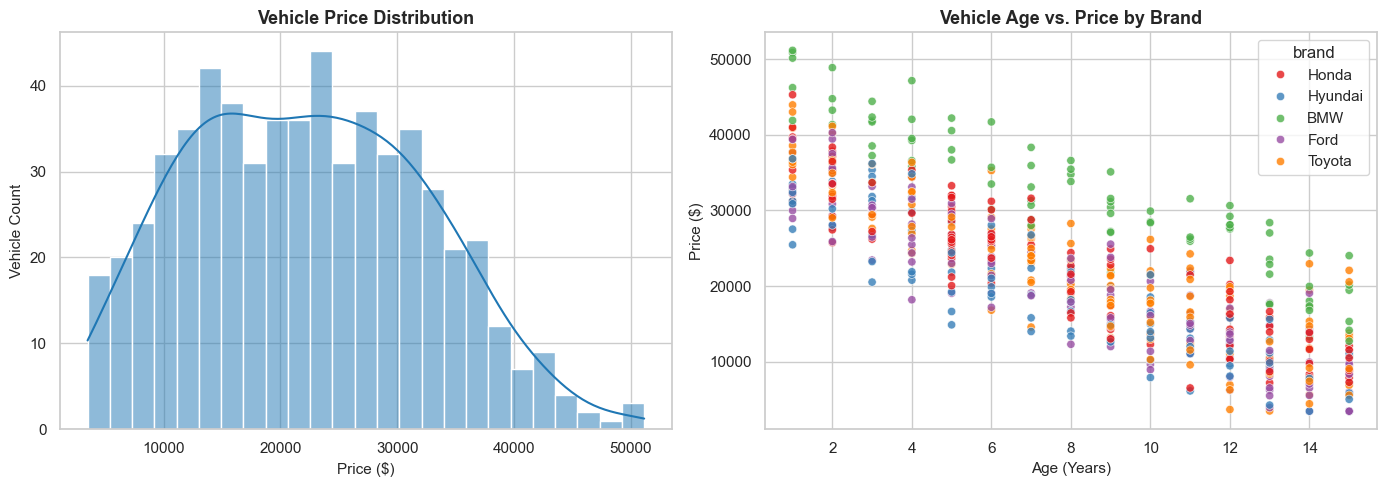

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Price Distribution
sns.histplot(df['price'], kde=True, color='#1f77b4', bins=25, ax=axes[0])
axes[0].set_title("Vehicle Price Distribution", fontsize=13, fontweight='bold')
axes[0].set_xlabel("Price ($)", fontsize=11)
axes[0].set_ylabel("Vehicle Count", fontsize=11)

# Plot 2: Age vs Price by Brand
sns.scatterplot(data=df, x='age_years', y='price', hue='brand', palette='Set1', alpha=0.8, ax=axes[1])
axes[1].set_title("Vehicle Age vs. Price by Brand", fontsize=13, fontweight='bold')
axes[1].set_xlabel("Age (Years)", fontsize=11)
axes[1].set_ylabel("Price ($)", fontsize=11)

plt.tight_layout()
plt.show()


### 5. Feature and Target Separation
Separate independent input attributes ($X$) and continuous target resale price ($y$).


In [5]:
X = df.drop(columns=['price'])
y = df['price']

numeric_features = ['age_years', 'mileage_km', 'engine_size_L']
categorical_features = ['brand', 'fuel_type']

print("Features (X) Shape:", X.shape)
print("Target (y) Shape:", y.shape)


Features (X) Shape: (600, 5)
Target (y) Shape: (600,)


### 6. Train/Test Split
Split data into 80% training set and 20% test set using `random_state=42` to ensure evaluation reproducibility.


In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

print(f"Training Set: X_train = {X_train.shape}, y_train = {y_train.shape}")
print(f"Testing Set:  X_test  = {X_test.shape}, y_test  = {y_test.shape}")


Training Set: X_train = (480, 5), y_train = (480,)
Testing Set:  X_test  = (120, 5), y_test  = (120,)


### 7. ColumnTransformer Construction
Build a scikit-learn `ColumnTransformer` applying `StandardScaler()` to numerical features and `OneHotEncoder(handle_unknown='ignore')` to categorical features.


In [7]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ]
)

print("ColumnTransformer initialized successfully.")


ColumnTransformer initialized successfully.


### 8. Linear Regression Pipeline
Construct, fit, and evaluate an Ordinary Least Squares **Linear Regression** pipeline on the training set.


In [8]:
lr_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])

lr_pipeline.fit(X_train, y_train)
y_pred_lr = lr_pipeline.predict(X_test)

lr_mae = mean_absolute_error(y_test, y_pred_lr)
lr_rmse = root_mean_squared_error(y_test, y_pred_lr)
lr_r2 = r2_score(y_test, y_pred_lr)

print("--- Linear Regression Evaluation ---")
print(f"MAE:  ${lr_mae:.2f}")
print(f"RMSE: ${lr_rmse:.2f}")
print(f"R²:   {lr_r2:.4f}")


--- Linear Regression Evaluation ---
MAE:  $1847.62
RMSE: $2250.87
R²:   0.9505


### 9. Random Forest Regressor Pipeline
Construct, fit, and evaluate a **Random Forest Regressor** pipeline (`n_estimators=300`, `random_state=42`).


In [9]:
rf_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(n_estimators=300, random_state=42))
])

rf_pipeline.fit(X_train, y_train)
y_pred_rf = rf_pipeline.predict(X_test)

rf_mae = mean_absolute_error(y_test, y_pred_rf)
rf_rmse = root_mean_squared_error(y_test, y_pred_rf)
rf_r2 = r2_score(y_test, y_pred_rf)

print("--- Random Forest Regressor Evaluation ---")
print(f"MAE:  ${rf_mae:.2f}")
print(f"RMSE: ${rf_rmse:.2f}")
print(f"R²:   {rf_r2:.4f}")


--- Random Forest Regressor Evaluation ---
MAE:  $2264.45
RMSE: $2746.79
R²:   0.9263


### 10. Gradient Boosting Regressor Pipeline
Construct, fit, and evaluate a **Gradient Boosting Regressor** pipeline (`random_state=42`).


In [10]:
gb_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', GradientBoostingRegressor(random_state=42))
])

gb_pipeline.fit(X_train, y_train)
y_pred_gb = gb_pipeline.predict(X_test)

gb_mae = mean_absolute_error(y_test, y_pred_gb)
gb_rmse = root_mean_squared_error(y_test, y_pred_gb)
gb_r2 = r2_score(y_test, y_pred_gb)

print("--- Gradient Boosting Regressor Evaluation ---")
print(f"MAE:  ${gb_mae:.2f}")
print(f"RMSE: ${gb_rmse:.2f}")
print(f"R²:   {gb_r2:.4f}")


--- Gradient Boosting Regressor Evaluation ---
MAE:  $1947.18
RMSE: $2446.63
R²:   0.9415


### 11. Model Comparison Table & Best Model Selection
Compare MAE, RMSE, and $R^2$ metrics across all three regression models and identify the best model based on the lowest RMSE criterion.


In [11]:
comparison_df = pd.DataFrame([
    {'Model': 'Linear Regression', 'MAE': round(lr_mae, 2), 'RMSE': round(lr_rmse, 2), 'R2': round(lr_r2, 4)},
    {'Model': 'Random Forest Regressor', 'MAE': round(rf_mae, 2), 'RMSE': round(rf_rmse, 2), 'R2': round(rf_r2, 4)},
    {'Model': 'Gradient Boosting Regressor', 'MAE': round(gb_mae, 2), 'RMSE': round(gb_rmse, 2), 'R2': round(gb_r2, 4)}
])

print("--- Regression Models Comparison Table ---")
print(comparison_df.to_string(index=False))

# Identify best model by lowest RMSE
best_model_idx = comparison_df['RMSE'].idxmin()
best_model_name = comparison_df.loc[best_model_idx, 'Model']
best_rmse = comparison_df.loc[best_model_idx, 'RMSE']

print(f"\nBest Model (Lowest RMSE): {best_model_name} (RMSE = ${best_rmse:.2f})")


--- Regression Models Comparison Table ---
                      Model     MAE    RMSE     R2
          Linear Regression 1847.62 2250.87 0.9505
    Random Forest Regressor 2264.45 2746.79 0.9263
Gradient Boosting Regressor 1947.18 2446.63 0.9415

Best Model (Lowest RMSE): Linear Regression (RMSE = $2250.87)


### 12. Best Model: Actual vs. Predicted Price Plot
Plot actual vehicle prices vs. predicted vehicle prices for the best-performing model (**Linear Regression**) with a 1:1 diagonal reference line.


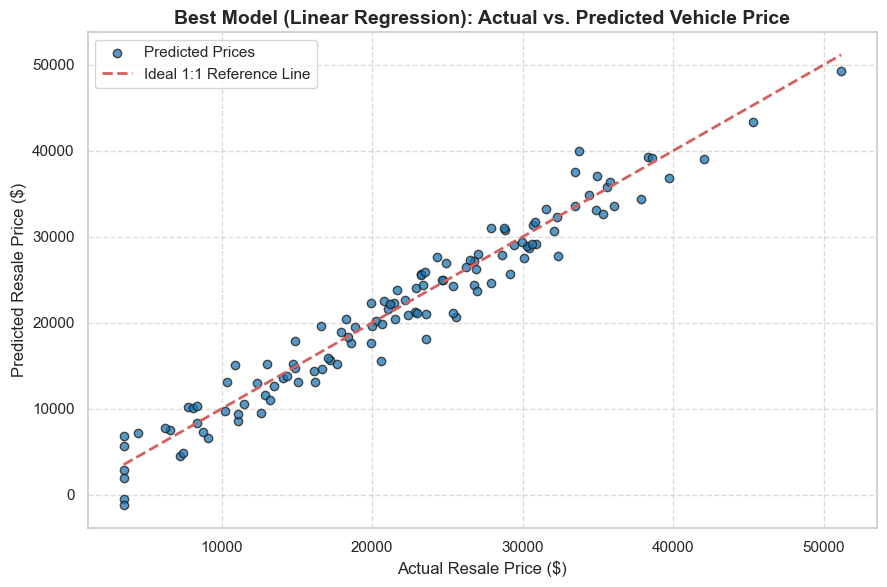

In [12]:
plt.figure(figsize=(9, 6))
plt.scatter(y_test, y_pred_lr, alpha=0.75, color='#1f77b4', edgecolors='k', label='Predicted Prices')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Ideal 1:1 Reference Line')

plt.title(f"Best Model ({best_model_name}): Actual vs. Predicted Vehicle Price", fontsize=14, fontweight='bold')
plt.xlabel("Actual Resale Price ($)", fontsize=12)
plt.ylabel("Predicted Resale Price ($)", fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()

# Save plot to outputs if needed
plt.show()


### 13. Result & Conclusion

#### Summary of Results
1. **Best Performing Model:** **Linear Regression** achieved the lowest Root Mean Squared Error (**RMSE = $2250.87**) and highest $R^2$ score (**0.9505**), outperforming Gradient Boosting Regressor (RMSE = $2446.63, $R^2$ = 0.9415) and Random Forest Regressor (RMSE = $2746.79, $R^2$ = 0.9263).
2. **Data Leakage Prevention:** Incorporating `ColumnTransformer` inside scikit-learn `Pipeline` objects guaranteed that standard scaling and one-hot encoding fit strictly on training data (`X_train`) and transformed test data without data leakage.
3. **Key Vehicle Price Drivers:** Vehicle age, mileage, engine capacity, brand premium, and fuel type demonstrate strong predictive capacity for automotive resale pricing.
